# 03 Train Symbolic SODT

- `z`: the frozen RoI Align pooled feature grid for each RPN proposal.
- `teacher_label`: the original Faster R-CNN classifier decision on that same pooled RoI.
- `bbox regression`: stays neural and is not part of SODT training.

This notebook is the canonical symbolic stage of the thesis pipeline:
1. load the trained Faster R-CNN teacher,
2. export symbolic RoI datasets for `trainval` and `test`,
3. train one configured SODT with TAO on the exported `trainval` RoIs,
4. evaluate that trained SODT on the held-out `test` export.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from symbolic.config import SymbolicTrainConfig
from symbolic.export import extract_dataset_from_teacher
from symbolic.train import train_symbolic_tree
from util.artifacts import next_run_artifacts, latest_run_checkpoint
from util.config import load_yaml
from util.device import select_device

PROJECT_ROOT = resolve_root()

train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
symbolic_train_config = load_yaml(Path("symbolic_train.yaml"), SymbolicTrainConfig)

device = select_device(train_config["device"])
class_names = tuple(train_config["dataset"]["class_names"])

checkpoint_dir = Path("checkpoints") / "neuro"
checkpoint_path = latest_run_checkpoint(checkpoint_dir)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

symbolic_dir = Path("checkpoints") / "symbolic"
next_run = next_run_artifacts(symbolic_dir)
teacher_trainval_path = symbolic_dir / "teacher_trainval_mixed_bg.pt"
teacher_test_path = symbolic_dir / "teacher_test_mixed_bg.pt"
symbolic_checkpoint_path = next_run.checkpoint_path
symbolic_summary_path = next_run.metrics_path

checkpoint_path, class_names

(PosixPath('checkpoints/neuro/run4.pt'),
 ('open', 'short', 'mouse_bite', 'spur', 'pinhole', 'spurious_copper'))

In [2]:
trainval_dataset = PCBDataset(train_config, "trainval.txt")
trainval_dataset.add_preprocess(test_preprocess())

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())

symbolic_data_config = symbolic_train_config["data"]
storage_dtype = str(symbolic_data_config["storage_dtype"])


def summarize_symbolic_export(export_path: Path, split_name: str):
    manifest = torch.load(export_path, map_location="cpu", weights_only=True)
    records = pd.DataFrame(manifest["records"])

    if records.empty:
        overview = pd.DataFrame(
            [
                {
                    "split": split_name,
                    "images": 0,
                    "total_rois": 0,
                    "background_rois": 0,
                    "positive_rois": 0,
                    "feature_shape": None,
                    "feature_cut": manifest.get("feature_cut"),
                    "symbolic_target": manifest.get("symbolic_target"),
                    "proposal_source": manifest.get("proposal_source"),
                }
            ]
        )
        class_counts = pd.DataFrame(columns=["split", "class_name", "count"])
        return manifest, overview, class_counts

    class_names = list(manifest["class_names"])
    label_counts = records["label_counts"].apply(pd.Series).fillna(0).sum(axis=0)
    label_counts = label_counts.reindex(range(len(class_names)), fill_value=0).astype(
        int
    )

    feature_shape = manifest.get("feature_shape")
    overview = pd.DataFrame(
        [
            {
                "split": split_name,
                "images": int(len(records)),
                "total_rois": int(records["num_rois"].sum()),
                "background_rois": int(label_counts.iloc[0]),
                "positive_rois": int(label_counts.iloc[1:].sum()),
                "feature_shape": "x".join(str(value) for value in feature_shape)
                if feature_shape
                else None,
                "feature_cut": manifest.get("feature_cut"),
                "symbolic_target": manifest.get("symbolic_target"),
                "proposal_source": manifest.get("proposal_source"),
            }
        ]
    )
    class_counts = pd.DataFrame(
        {
            "split": split_name,
            "class_name": class_names,
            "count": label_counts.tolist(),
        }
    )
    return manifest, overview, class_counts


len(trainval_dataset), len(test_dataset)

(1000, 500)

In [3]:
extract_dataset_from_teacher(
    model=model,
    dataset=trainval_dataset,
    output_path=teacher_trainval_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)
extract_dataset_from_teacher(
    model=model,
    dataset=test_dataset,
    output_path=teacher_test_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)

teacher_trainval_path, teacher_test_path

(PosixPath('checkpoints/symbolic/teacher_trainval_mixed_bg.pt'),
 PosixPath('checkpoints/symbolic/teacher_test_mixed_bg.pt'))

In [4]:
trainval_manifest, trainval_overview, trainval_counts = summarize_symbolic_export(
    teacher_trainval_path,
    "trainval",
)
test_manifest, test_overview, test_counts = summarize_symbolic_export(
    teacher_test_path,
    "test",
)

display(pd.concat([trainval_overview, test_overview], ignore_index=True))
display(pd.concat([trainval_counts, test_counts], ignore_index=True))

,split,images,total_rois,background_rois,positive_rois,feature_shape,feature_cut,symbolic_target,proposal_source
0,trainval,1000,1000000,857706,142294,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess
1,test,500,500000,433107,66893,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess


,split,class_name,count
0,trainval,__background__,857706
1,trainval,open,27913
2,trainval,short,19622
3,trainval,mouse_bite,28557
4,trainval,spur,23055
5,trainval,pinhole,21091
6,trainval,spurious_copper,22056
7,test,__background__,433107
8,test,open,14322
9,test,short,9775


In [5]:
summary = train_symbolic_tree(
    export_path=teacher_trainval_path,
    output_path=symbolic_checkpoint_path,
    summary_path=symbolic_summary_path,
    heldout_export_path=teacher_test_path,
    config=symbolic_train_config,
)

Loading symbolic training export from checkpoints/symbolic/teacher_trainval_mixed_bg.pt...
Symbolic training data ready in 1m 59s.
Loaded 28000 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=6, lambda=50, alpha=0.9.
Workload check: 15 TAO iterations and up to 945 LIBLINEAR node fits.
Each TAO iteration gets its own node-fit progress bar and remains visible after completion.


TAO 15/15 nodes: 100%|██████████| 63/63 [00:14<00:00,  4.44it/s, iteration_done | mimic=0.9998 nz=3749]


### Single SODT Student Metrics

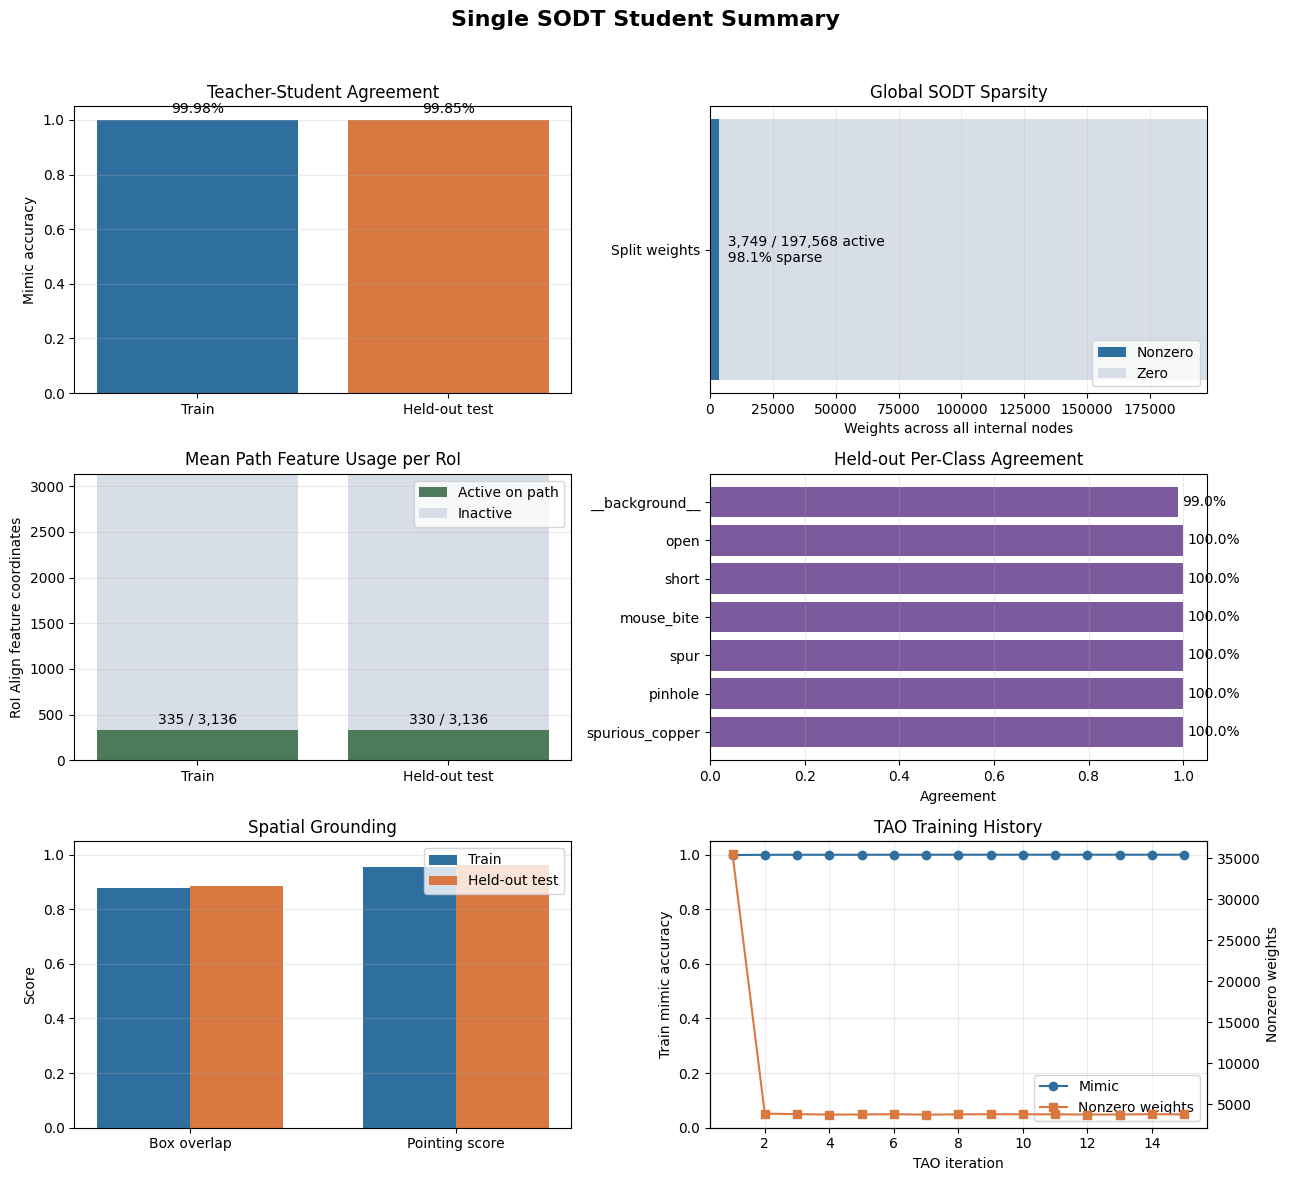

{'train_mimic_accuracy': 0.9997857142857143,
 'heldout_mimic_accuracy': 0.9985,
 'nonzero_weights': 3749,
 'total_split_weights': 197568,
 'global_weight_sparsity': 0.9810242549400713,
 'heldout_mean_path_features': 330.2375714285714,
 'roi_feature_count': 3136,
 'heldout_review_note': 'Held-out test evaluates the trained SODT once. It does not participate in training.'}

In [6]:
train_metrics = summary["model"]["metrics"]
train_report = summary["train_report"]
heldout_report = summary["heldout_review"]["report"]

feature_dim = int(np.prod(summary["feature_shape"]))
total_split_weights = int(train_metrics["num_internal_nodes"] * feature_dim)
nonzero_weights = int(train_metrics["nonzero_weights"])
zero_weights = max(total_split_weights - nonzero_weights, 0)
weight_sparsity = zero_weights / max(total_split_weights, 1)

train_mimic = float(train_report["mimic_accuracy"])
test_mimic = float(heldout_report["mimic_accuracy"])
train_path_features = float(train_report["mean_path_feature_count"])
test_path_features = float(heldout_report["mean_path_feature_count"])

class_agreement = heldout_report["per_class_agreement_vs_teacher"]
class_names = list(class_agreement.keys())
class_values = [float(class_agreement[name]) for name in class_names]

history = pd.DataFrame(summary["history"])

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle("Single SODT Student Summary", fontsize=16, fontweight="bold")

ax = axes[0, 0]
accuracy_labels = ["Train", "Held-out test"]
accuracy_values = [train_mimic, test_mimic]
accuracy_bars = ax.bar(accuracy_labels, accuracy_values, color=["#2F6F9F", "#D97941"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mimic accuracy")
ax.set_title("Teacher-Student Agreement")
ax.bar_label(
    accuracy_bars, labels=[f"{value:.2%}" for value in accuracy_values], padding=3
)
ax.grid(axis="y", alpha=0.25)

ax = axes[0, 1]
ax.barh(["Split weights"], [nonzero_weights], color="#2F6F9F", label="Nonzero")
ax.barh(
    ["Split weights"],
    [zero_weights],
    left=[nonzero_weights],
    color="#D7DEE8",
    label="Zero",
)
ax.set_xlim(0, total_split_weights)
ax.set_xlabel("Weights across all internal nodes")
ax.set_title("Global SODT Sparsity")
ax.text(
    nonzero_weights,
    0,
    f"  {nonzero_weights:,} / {total_split_weights:,} active\n  {weight_sparsity:.1%} sparse",
    va="center",
)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[1, 0]
path_labels = ["Train", "Held-out test"]
path_values = [train_path_features, test_path_features]
unused_path_values = [max(feature_dim - value, 0) for value in path_values]
ax.bar(path_labels, path_values, color="#4C7A5A", label="Active on path")
ax.bar(
    path_labels,
    unused_path_values,
    bottom=path_values,
    color="#D7DEE8",
    label="Inactive",
)
ax.set_ylim(0, feature_dim)
ax.set_ylabel("RoI Align feature coordinates")
ax.set_title("Mean Path Feature Usage per RoI")
for index, value in enumerate(path_values):
    ax.text(
        index,
        value + (feature_dim * 0.02),
        f"{value:,.0f} / {feature_dim:,}",
        ha="center",
    )
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)

ax = axes[1, 1]
y_positions = np.arange(len(class_names))
class_bars = ax.barh(y_positions, class_values, color="#7C5A9E")
ax.set_yticks(y_positions)
ax.set_yticklabels(class_names)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Agreement")
ax.set_title("Held-out Per-Class Agreement")
ax.bar_label(class_bars, labels=[f"{value:.1%}" for value in class_values], padding=3)
ax.grid(axis="x", alpha=0.25)

ax = axes[2, 0]
spatial_metric_names = ["box_grounded_roi_overlap", "pointing_score"]
x = np.arange(len(spatial_metric_names))
bar_width = 0.35
train_spatial = [float(train_report[name]) for name in spatial_metric_names]
test_spatial = [float(heldout_report[name]) for name in spatial_metric_names]
ax.bar(
    x - bar_width / 2, train_spatial, width=bar_width, color="#2F6F9F", label="Train"
)
ax.bar(
    x + bar_width / 2,
    test_spatial,
    width=bar_width,
    color="#D97941",
    label="Held-out test",
)
ax.set_xticks(x)
ax.set_xticklabels(["Box overlap", "Pointing score"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding")
ax.legend()
ax.grid(axis="y", alpha=0.25)

ax = axes[2, 1]
if not history.empty:
    ax.plot(
        history["iteration"],
        history["mimic_accuracy"],
        color="#2F6F9F",
        marker="o",
        label="Mimic",
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("TAO iteration")
    ax.set_ylabel("Train mimic accuracy")
    ax.grid(alpha=0.25)
    ax_nonzero = ax.twinx()
    ax_nonzero.plot(
        history["iteration"],
        history["nonzero_weights"],
        color="#D97941",
        marker="s",
        label="Nonzero weights",
    )
    ax_nonzero.set_ylabel("Nonzero weights")
    lines, labels = ax.get_legend_handles_labels()
    extra_lines, extra_labels = ax_nonzero.get_legend_handles_labels()
    ax.legend(lines + extra_lines, labels + extra_labels, loc="lower right")
ax.set_title("TAO Training History")

fig.tight_layout(rect=[0, 0, 1, 0.96])
display(Markdown("### Single SODT Student Metrics"))
plt.show()

{
    "train_mimic_accuracy": train_mimic,
    "heldout_mimic_accuracy": test_mimic,
    "nonzero_weights": nonzero_weights,
    "total_split_weights": total_split_weights,
    "global_weight_sparsity": weight_sparsity,
    "heldout_mean_path_features": test_path_features,
    "roi_feature_count": feature_dim,
    "heldout_review_note": summary["heldout_review"]["note"],
}